# 👥🚀 k-NN and Linear SVM

<a href="https://colab.research.google.com/github/rubenfonnegra/machine_learning/blob/master/Sem_03/knn_linear_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> 
<a href="https://github.com/rubenfonnegra/machine_learning/blob/master/Sem_03/knn_linear_svm.ipynb" target="_parent"><img src="https://img.shields.io/badge/%E2%80%8B-Open%20in%20Github-blue?logo=github" alt="Open In Github"/></a> 


### Learning objectives

By the end of this notebook, you will be able to:

- Understand neighbor voting and Euclidean distance.
- Understand linear decision boundaries, margins, and support vectors.
- Train both models with `scikit-learn`.
- Study the effects of `k` and `C`.
- Compare metrics, decision boundaries, and execution time.

### Documentation

- [```k-NN```](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier)
- [```SVM```](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)

---

> **📘 Machine Learning**  
> **Author:** Rubén D. Fonnegra, Ph.D. \
> **Institution:** Institución Universitaria Pascual Bravo  
> © 2026 · Educational use with attribution

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

### k-NN: Main Idea

k-NN predicts the class of a new observation using the labels of its nearest neighbors.

Basic procedure:

1. Select `k`.
2. Calculate distances.
3. Find the `k` closest observations.
4. Use majority voting.

A common distance measure is:

$$
d(\mathbf{x},\mathbf{y})
=
\sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
$$


In [2]:
def euclidean_distance(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return np.sqrt(np.sum((a - b) ** 2))

print(euclidean_distance([2, 3], [5, 7]))


5.0


#### Effect of k

- Small `k`: flexible, but sensitive to noise.
- Large `k`: smoother, but may underfit.
- `k` should be selected using validation.


### Linear SVM: Main Idea

A linear SVM searches for a straight boundary that separates classes while maximizing the margin.

The decision function is:

$$
f(\mathbf{x})=\mathbf{m}^{T}\mathbf{x}+b
$$

The closest observations are called **support vectors**.

#### Parameter C

- Small `C`: stronger regularization and wider margin.
- Large `C`: weaker regularization and greater emphasis on training accuracy.


### Load a Binary Iris Dataset

In [3]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

# Keep Versicolor and Virginica
df = df[df["target"].isin([1, 2])].copy()

features = ["petal length (cm)", "petal width (cm)"]
X = df[features]
y = df["target"].map({1: 0, 2: 1})

print(X.shape)
print(y.value_counts())
df.head()


(100, 2)
target
0    50
1    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
50,7.0,3.2,4.7,1.4,1,versicolor
51,6.4,3.2,4.5,1.5,1,versicolor
52,6.9,3.1,4.9,1.5,1,versicolor
53,5.5,2.3,4.0,1.3,1,versicolor
54,6.5,2.8,4.6,1.5,1,versicolor


In [4]:
dict(enumerate(iris.target_names))

{0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}

### Visualize the Data

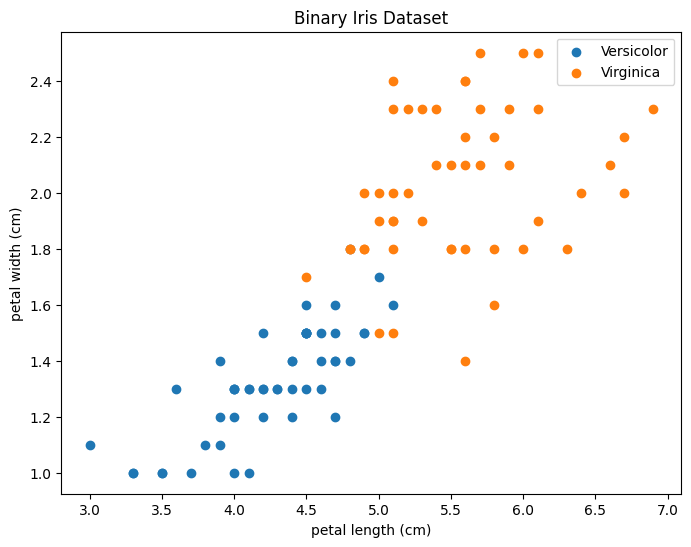

In [5]:
plt.figure(figsize=(8, 6))

for label, name in [(0, "Versicolor"), (1, "Virginica")]:
    mask = y == label
    plt.scatter(
        X.loc[mask, features[0]],
        X.loc[mask, features[1]],
        label=name
    )

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("Binary Iris Dataset")
plt.legend()
plt.show()


### Convert data into arrays

In [6]:
X, y = X.to_numpy() , y.to_numpy()

print (type(X), type(y))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


### Train k-NN

In [7]:
knn = KNeighborsClassifier( n_neighbors = 7, metric="euclidean")

knn.fit( X , y )
knn_pred = knn.predict(X)

print("k-NN trained.")


k-NN trained.


### Train Linear SVM

In [8]:
svm = SVC(kernel="linear", C=1.0)

svm.fit( X , y )
svm_pred = svm.predict(X)

print("Linear SVM trained.")

Linear SVM trained.


### Compare Predictions

In [9]:
pd.DataFrame({
    "Actual": y ,
    "k-NN"  : knn_pred ,
    "Linear SVM": svm_pred
}).head(10)


,Actual,k-NN,Linear SVM
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
5,0,0,0
6,0,0,0
7,0,0,0
8,0,0,0
9,0,0,0


### Compare Evaluation Metrics

In [10]:
print ("k-NN --> Accuracy: {0}".format (accuracy_score(y, knn_pred)))
print ("SVM  --> Accuracy: {0}".format (accuracy_score(y, svm_pred)))

k-NN --> Accuracy: 0.95
SVM  --> Accuracy: 0.95


### Plot Decision Boundaries

In [11]:
from sklearn.base import ClassifierMixin
from matplotlib.figure import Figure


In [12]:
def plot_classifier (classifier: ClassifierMixin, 
    X: np.ndarray, y: np.ndarray,
    features: list[str] | None = ["x1", "x2"],
    title: str | None = None,
    fig_size: tuple[int, int] | None = None,
    labels : list[str] | None = None,
    offset = 0.5,
    res = 100,
    cmap = "Paired",
        ) -> Figure:
    
    # def plot_data(ax = ax, plot = False):
    #     if not False:
    #         _, ax = plt.subplots(figsize=fig_size)
    #         ax.scatter(X[:, 0], X[:, 1], y, edgecolors='k', cmap=cmap)
    #         ax.title("Data visualization")
    #         ax.set_xlabel(features[0])
    #         ax.set_ylabel(features[1])

    # Decision Boundary
    x_min, x_max = np.min(X[:, 0]) - offset, np.max(X[:, 0]) + offset
    y_min, y_max = np.min(X[:, 1]) - offset, np.max(X[:, 1]) + offset
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, res), np.linspace(y_min, y_max, res))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_pred = classifier.predict(grid).reshape(xx.shape)
    y_pred = classifier.predict(X)
    acc = accuracy_score(y, y_pred)

    # Plot
    fig_size = (6,5) if fig_size == None else fig_size

    _, ax = plt.subplots(figsize=fig_size)
    ax.pcolormesh(xx, yy, grid_pred, cmap=cmap)
    prediction_plot = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=cmap)
    ax.contour(xx, yy, grid_pred, levels=[-1, 0, 1], linestyles=["--"], linewidths=1, colors='k', alpha=0.8)
 
    if labels == None:
        ax.legend(*prediction_plot.legend_elements(), title="Clases", loc="upper right")
    else: ax.legend(prediction_plot.legend_elements()[0], labels=labels, title="Clases", loc="upper right")


    ax.set_title(f"Model: {title if title != None else str(classifier)}, Acc: {acc:.2f}")
    ax.set_xlabel(features[0])
    ax.set_ylabel(features[1])
    
    # SVC
    if isinstance(classifier, SVC):
        support_vectors = classifier.support_vectors_
        ax.scatter(support_vectors[:, 0], support_vectors[:, 1], s=80, facecolors="none", edgecolors="k")

    plt.tight_layout()
    plt.show()



In [ ]:
plot_classifier

Signature:
plot_classifier(
    classifier: sklearn.base.ClassifierMixin,
    X: numpy.ndarray,
    y: numpy.ndarray,
    features: list[str] | None = ['x1', 'x2'],
    title: str | None = None,
    fig_size: tuple[int, int] | None = None,
    labels: list[str] | None = None,
    offset=0.5,
    res=100,
    cmap='Paired',
) -> matplotlib.figure.Figure
Docstring: <no docstring>
File:      c:\users\windows 11\appdata\local\temp\ipykernel_5636\2180767929.py
Type:      function

In [ ]:
def plot_decision_boundary (clf, X, y, grid_res=None, grid_size=None, offset=0.1, n_classes=3, ax = None, ax_names = None, ax_title = None):
    #
    from sklearn import svm
    import warnings
    warnings.filterwarnings("ignore")
    
    assert X.shape[1] == 2, ValueError('Num features (cols) must be 2. Current: {0}'.format(X.shape[1]))
    if not grid_size and not grid_res: grid_size = (100, 100) 
    
    # Min max values for the decision bounding grid
    h_min, h_max = X[:, 0].min()-offset, X[:, 0].max()+offset
    v_min, v_max = X[:, 1].min()-offset, X[:, 1].max()+offset

    # Create the grid
    if grid_size: 
        h_array = np.linspace( h_min , h_max , grid_size[0])
        v_array = np.linspace( v_min , v_max , grid_size[1])
    else:
        h_array = np.arange( h_min , h_max , grid_res[0])
        v_array = np.arange( v_min , v_max , grid_res[1])
        
    h_grid, v_grid = np.meshgrid(h_array, v_array)

    # Predict
    predictions = clf.predict(np.c_[h_grid.ravel(), v_grid.ravel()])
    
    # Reshape back to original dim
    predictions = predictions.reshape( h_grid.shape )
    
    # Draw everything
    if ax == None: _, ax = plt.subplots (figsize=(7,5))
    ax.pcolormesh( h_grid , v_grid , predictions , cmap = plt.cm.Paired)
    ax.contour( h_grid , v_grid , predictions , colors='k', alpha=0.8, linewidth=1, linestyles='-', levels=np.arange(0, n_classes))

    # show the scatter
    scatter = ax.scatter ( X[:, 0] , X[:, 1] , c = y , edgecolors='k', cmap=plt.cm.Paired)
    handles, _ = scatter.legend_elements()
    ax.legend(handles, np.unique_values(y))
    
    if isinstance(clf, svm.SVC):
        ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=80, facecolors="none", edgecolors="k")

    ax.set_xlim(h_min, h_max)
    ax.set_ylim(v_min, v_max)
    
    if ax_names != None:
        ax.set_xlabel(ax_names[0]), ax.set_ylabel(ax_names[1])
    
    if ax_title != None:
        ax.set_title(str(ax_title))

    ax.set_xticks(())
    ax.set_yticks(())




In [ ]:
plot_decision_boundary (knn, X, y, grid_size=(100, 100), offset=0.1, 
                        ax_names = [features[0], features[1]], ax_title = "k-NN Decision Boundary")

In [ ]:
plot_classifier(knn, X, y, features, res=1000)
plot_classifier(svm, X, y, features)

In [ ]:
plot_decision_boundary (svm, X, y, grid_size=(100, 100), offset=0.1, 
                        ax_names = ["Versicolor", "Virginica"], ax_title = "SVM Decision Boundary")

### Inspect SVM Support Vectors

In [ ]:
support_vectors = svm.support_vectors_

support_df = pd.DataFrame(
    support_vectors,
    columns=features
)

print("Number of support vectors:", len(support_df))
support_df

### Study Different k Values

In [ ]:
knn_k3 = KNeighborsClassifier(n_neighbors=3)
knn_k7 = KNeighborsClassifier(n_neighbors=7)
knn_k9 = KNeighborsClassifier(n_neighbors=9)

knn_k3.fit( X , y )
knn_k7.fit( X , y )
knn_k9.fit( X , y )

knn_k3_pred = knn_k3.predict(X)
knn_k7_pred = knn_k7.predict(X)
knn_k9_pred = knn_k9.predict(X)


In [ ]:
print ("k=3 --> Accuracy: {0}".format (accuracy_score(y, knn_k3_pred)))
print ("k=7 --> Accuracy: {0}".format (accuracy_score(y, knn_k7_pred)))
print ("k=9 --> Accuracy: {0}".format (accuracy_score(y, knn_k9_pred)))

In [ ]:
_, axes = plt.subplots (1, 3, figsize = (12,4))

plot_decision_boundary ( knn_k3 , X, y, grid_size=(100, 100), offset=0.1, ax = axes[0],
                        ax_names = ["Versicolor", "Virginica"], ax_title = "k = 3")

plot_decision_boundary ( knn_k7 , X, y, grid_size=(100, 100), offset=0.1, ax = axes[1],
                        ax_names = ["Versicolor", "Virginica"], ax_title = "k = 7")

plot_decision_boundary ( knn_k9 , X, y, grid_size=(100, 100), offset=0.1, ax = axes[2],
                        ax_names = ["Versicolor", "Virginica"], ax_title = "k = 9")

### Study Different C Values

In [ ]:
svm_l = SVC(kernel="linear", C=0.1)
svm_m = SVC(kernel="linear", C=1  )
svm_h = SVC(kernel="linear", C=10 )

svm_l.fit( X , y )
svm_m.fit( X , y )
svm_h.fit( X , y )

svm_l_pred = svm_l.predict(X)
svm_m_pred = svm_m.predict(X)
svm_h_pred = svm_h.predict(X)


In [ ]:
print ("C=0.1 --> Accuracy: {0}".format (accuracy_score(y, svm_l_pred)))
print ("C=1   --> Accuracy: {0}".format (accuracy_score(y, svm_m_pred)))
print ("C=10  --> Accuracy: {0}".format (accuracy_score(y, svm_h_pred)))

In [ ]:
_, axes = plt.subplots (1, 3, figsize = (12,4))

plot_decision_boundary ( svm_l , X, y, grid_size=(100, 100), offset=0.1, ax = axes[0],
                        ax_names = ["Versicolor", "Virginica"], ax_title = "C=0.1")

plot_decision_boundary ( svm_m , X, y, grid_size=(100, 100), offset=0.1, ax = axes[1],
                        ax_names = ["Versicolor", "Virginica"], ax_title = "C=1  ")

plot_decision_boundary ( svm_h , X, y, grid_size=(100, 100), offset=0.1, ax = axes[2],
                        ax_names = ["Versicolor", "Virginica"], ax_title = "C=10 ")

### Main Comparison

| Characteristic | k-NN | Linear SVM |
|---|---|---|
| Strategy | Neighbor voting | Maximum-margin boundary |
| Main parameter | `k` | `C` |
| Training | Very fast | Optimization required |
| Prediction | Can be slower | Usually fast |
| Boundary | Flexible and local | Linear |
| Scaling | Important | Important |
| Memory | Stores training data | Stores coefficients/support vectors |
| Best suited for | Local patterns | Approximately linear separation |


## Practice Exercises

### Exercise 1
Create a small dataset and manually classify one query point using `k=3`.


In [ ]:
# Your code here

### Exercise 2
Compare k-NN models with `k=1`, `k=3`, `k=7`, and `k=15`.


In [ ]:
# Your code here

### Exercise 3
Compare linear SVM models with `C=0.01`, `C=1`, and `C=100`.


In [ ]:
# Your code here

### Exercise 4
Train both models without feature scaling and compare the results.


In [ ]:
# Your code here

---

## 📄 Attribution

This notebook was developed by **Rubén D. Fonnegra** as educational material for Machine Learning courses at **Institución Universitaria Pascual Bravo**.
You may use, share, and adapt this material for educational purposes, provided that appropriate credit is given to the original author.

**Suggested citation:**
> Fonnegra Tarazona, R. D. (2026). *k-NN and Linear SVM: Machine Learning Notebook*. Institución Universitaria Pascual Bravo.